# 03 · YouTubers × YouTube

Built on `polarization.py`. Writes `user_counts.csv`, `channel_df.csv`, `video_df.csv`.

The old notebook had no `>= 20` threshold — the politician one did. That asymmetry is fixed here; both cells now use `P.MIN_COMMENTS`.

In [1]:
import sys
sys.path.append(".")          # polarization.py sits next to this notebook

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import polarization as P

In [2]:
PLATFORM      = "YouTube"
PRODUCER_TYPE = "YouTuber"

OUT = "D:/School/2026 Spring/KR_Polarization/dataset/influencers/youtube"

## 1. Load comments

In [ ]:
df = P.flatten_youtube_comments(
    "D:/School/2026 Spring/KR_Polarization/datasets/influencers/youtube/scraped_comments_merged.jsonl"
)

print(df.shape)
df.head()

  6,665,461 rows -> 1,982 MB in memory
(6665461, 11)


,video_id,video_title,channel_id,channel_name,channel_url,comment_id,parent_id,type,author,like_count,timestamp
0,y8HrkphSefk,[충격단독] 나는 포주다 (민주당 파주시장 후보 손배찬),UC0M-_02RJqMlGTKUjF1WhJg,unknown,https://www.youtube.com/@HOVERLAB2018,Ugzc5RHxdmyJ-9sa3dF4AaABAg,None,comment,@세모철학,6,2026-05-10T14:54:40Z
1,y8HrkphSefk,[충격단독] 나는 포주다 (민주당 파주시장 후보 손배찬),UC0M-_02RJqMlGTKUjF1WhJg,unknown,https://www.youtube.com/@HOVERLAB2018,Ugz72iO-9GHqZIBmM6J4AaABAg,None,comment,@조선희-t7q,1,2026-05-10T14:38:45Z
2,y8HrkphSefk,[충격단독] 나는 포주다 (민주당 파주시장 후보 손배찬),UC0M-_02RJqMlGTKUjF1WhJg,unknown,https://www.youtube.com/@HOVERLAB2018,UgwYz9DpO0medf76nN54AaABAg,None,comment,@finebowl-r4m,1,2026-05-10T13:29:32Z
3,y8HrkphSefk,[충격단독] 나는 포주다 (민주당 파주시장 후보 손배찬),UC0M-_02RJqMlGTKUjF1WhJg,unknown,https://www.youtube.com/@HOVERLAB2018,UgzP9201ArIqncptYrB4AaABAg,None,comment,@이지은-j1m6c,5,2026-05-10T13:23:01Z
4,y8HrkphSefk,[충격단독] 나는 포주다 (민주당 파주시장 후보 손배찬),UC0M-_02RJqMlGTKUjF1WhJg,unknown,https://www.youtube.com/@HOVERLAB2018,UgzL56B41QxWAInEVTh4AaABAg,None,comment,@승모홍-z2r,6,2026-05-10T13:18:44Z


In [4]:
df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    utc=True,
    errors="coerce"
)

print("Earliest:", df["timestamp"].min())
print("Latest:", df["timestamp"].max())

Earliest: 2014-04-28 18:03:22+00:00
Latest: 2026-05-28 17:48:16+00:00


In [4]:
summary = pd.DataFrame({
    "Total": [
        df["channel_id"].nunique(),
        df["video_id"].nunique(),
        df["comment_id"].nunique(),
        df["author"].nunique()
    ]
}, index=[
    "Channels",
    "Videos",
    "Comments",
    "Users"
])

summary

,Total
Channels,172
Videos,24065
Comments,6665461
Users,1195041


In [4]:
df["type"].value_counts()

type
comment    6018333
reply       647128
Name: count, dtype: int64

## 2. Ideology lookup

In [4]:
ideo = P.youtuber_ideology(
    "D:/School/2026 Spring/KR_Polarization/dataset/Influencer_YouTube.xlsx",
    PLATFORM,
    url_col="YouTube Link",
    name_col="Channel",
    stance_col="Stance",
)

ideo.head()

  dropping 12 rows with unusable stance: {'nan'}
  ideology map (YouTube): 197 producers -> {'right': 113, 'left': 84}


,key,producer_name,ideology
0,https://www.youtube.com/@HOVERLAB2018,가로세로연구소,right
1,https://www.youtube.com/@gamdonglan,감동란,right
2,https://www.youtube.com/@KangshinupTV,강신업,right
3,https://www.youtube.com/@inssait,강용석의 인싸it,right
4,https://www.youtube.com/@%EA%B3%A0%EB%85%BC,고논,right


In [5]:
ideo["ideology"].value_counts()

ideology
right    113
left      84
Name: count, dtype: int64

## 3. Prepare

Dedupe on `comment_id`, attach ideology, drop producer self-comments, fold
`independent` into left. Read the printout: a low match rate means the lookup
keys don't line up, and a big drop at the dedupe step means the source file
holds each record more than once.

In [6]:
prepared = P.prepare(df, ideo, PLATFORM)

  dedupe on comment_id: 6,665,461 -> 6,665,461
  ideology matched: 6,665,461 / 6,665,461 (100.0%)
  self-comments dropped: 0


## 4. User-level measures

In [8]:
uc_5, _ = P.user_measures(prepared, min_comments=5)
uc_10, _ = P.user_measures(prepared, min_comments=10)
uc_20, _ = P.user_measures(prepared, min_comments=20)

  authors: 1,195,041 | active (>=5): 304,020 | comments kept: 5,174,292
  users on >1 producer: 200,902 / 304,020 (66.1%)
  authors: 1,195,041 | active (>=10): 153,702 | comments kept: 4,193,888
  users on >1 producer: 117,270 / 153,702 (76.3%)
  authors: 1,195,041 | active (>=20): 67,840 | comments kept: 3,040,699
  users on >1 producer: 56,298 / 67,840 (83.0%)


In [9]:
for threshold, uc in [
    (5, uc_5),
    (10, uc_10),
    (20, uc_20)
]:
    # Add labels
    uc["producer_type"] = PRODUCER_TYPE
    uc["platform"] = PLATFORM

    # Verify labels
    pt = set(uc["producer_type"])
    pl = set(uc["platform"])

    assert pt == {PRODUCER_TYPE}
    assert pl == {PLATFORM}

    # Save
    uc.to_csv(
        f"{OUT}/user_counts_{threshold}.csv",
        index=False,
        encoding="utf-8-sig"
    )

    print(
        f"user_counts_{threshold}: "
        f"{len(uc):,} users | {pt} | {pl} | saved"
    )

user_counts_5: 304,020 users | {'YouTuber'} | {'YouTube'} | saved
user_counts_10: 153,702 users | {'YouTuber'} | {'YouTube'} | saved
user_counts_20: 67,840 users | {'YouTuber'} | {'YouTube'} | saved


In [8]:
user_counts, comment_users = P.user_measures(prepared, min_comments=P.MIN_COMMENTS)

user_counts = P.tag(user_counts, PLATFORM, PRODUCER_TYPE)
user_counts.head()

  authors: 1,195,041 | active (>=20): 67,840 | comments kept: 3,040,699
  users on >1 producer: 56,298 / 67,840 (83.0%)


,author,left,right,user_bias,user_cross_cut,total,n_producers,activity_band,platform,producer_type
0,,15,16,0.032258,0.998959,31,7,20–49,YouTube,YouTuber
1,@---cc4pr,31,2,-0.878788,0.227732,33,4,20–49,YouTube,YouTuber
2,@---qy9zm,3,27,0.800000,0.360000,30,6,20–49,YouTube,YouTuber
3,@---vq7gm,0,23,1.000000,0.000000,23,5,20–49,YouTube,YouTuber
4,@-2-275,0,129,1.000000,0.000000,129,9,100–299,YouTube,YouTuber


In [9]:
youtube_summary = {
    "Producers/Channels": comment_users["channel_id"].nunique(),
    "YouTube videos": comment_users["video_id"].nunique(),
    "YouTube comments": comment_users["comment_id"].nunique(),
}

youtube_summary

{'Producers/Channels': 172,
 'YouTube videos': 23496,
 'YouTube comments': 3040699}

In [9]:
user_counts[["user_bias", "user_cross_cut", "total", "n_producers"]].describe()

,user_bias,user_cross_cut,total,n_producers
count,67840.000000,67840.000000,67840.000000,67840.000000
mean,0.422868,0.083212,44.821624,5.022553
std,0.859058,0.182151,62.781730,3.440604
min,-1.000000,0.000000,20.000000,0.000000
25%,-0.800000,0.000000,24.000000,2.000000
50%,1.000000,0.000000,32.000000,5.000000
75%,1.000000,0.092971,49.000000,7.000000
max,1.000000,1.000000,9022.000000,27.000000


In [10]:
bias_neg1_pct = (user_counts["user_bias"] == -1).mean() * 100
bias_pos1_pct = (user_counts["user_bias"] == 1).mean() * 100

print(f"Bias = -1: {bias_neg1_pct:.2f}%")
print(f"Bias = +1: {bias_pos1_pct:.2f}%")

Bias = -1: 16.54%
Bias = +1: 52.84%


In [11]:
zero_pct = (user_counts["user_cross_cut"] == 0).mean() * 100
positive_pct = (user_counts["user_cross_cut"] > 0).mean() * 100

print(f"Cross-cut = 0: {zero_pct:.2f}%")
print(f"Cross-cut > 0: {positive_pct:.2f}%")

Cross-cut = 0: 69.38%
Cross-cut > 0: 30.62%


### Producers per user

`user_bias` only varies for users who comment across more than one producer.
If this share is low the measure collapses to +/-1 and cross-cutting goes to 0
by construction rather than by finding.

In [10]:
multi = (user_counts["n_producers"] > 1).sum()

print(f"users on >1 producer: {multi:,} / {len(user_counts):,} "
      f"({multi / len(user_counts):.1%})")

user_counts["n_producers"].describe()

users on >1 producer: 56,298 / 67,840 (83.0%)


count    67840.000000
mean         5.022553
std          3.440604
min          0.000000
25%          2.000000
50%          5.000000
75%          7.000000
max         27.000000
Name: n_producers, dtype: float64

## 5. Distributions

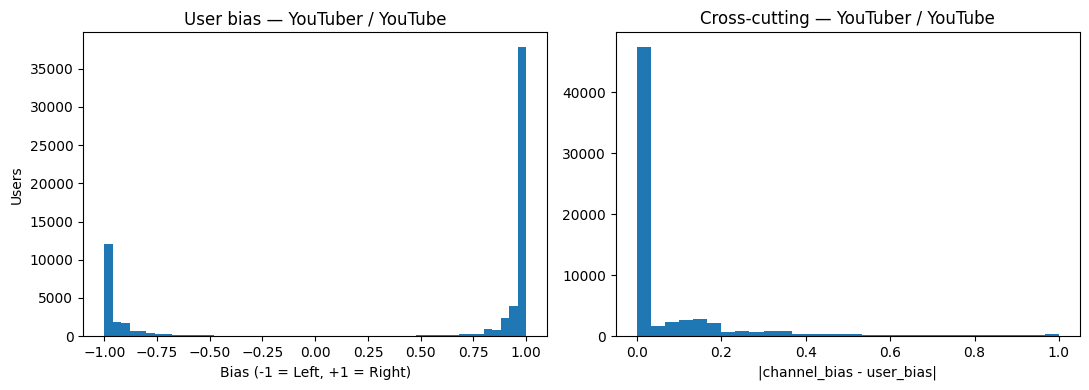

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].hist(user_counts["user_bias"], bins=50)
ax[0].set_title(f"User bias — {PRODUCER_TYPE} / {PLATFORM}")
ax[0].set_xlabel("Bias (-1 = Left, +1 = Right)")
ax[0].set_ylabel("Users")

ax[1].hist(user_counts["user_cross_cut"].dropna(), bins=30)
ax[1].set_title(f"Cross-cutting — {PRODUCER_TYPE} / {PLATFORM}")
ax[1].set_xlabel("|channel_bias - user_bias|")

plt.tight_layout()
plt.show()

### Audience size

`producer_stats.csv` comes from `fetch_audience_size.py` — YouTube subscriber
counts via the Data API, Instagram follower counts via instaloader. If the file
isn't there yet the notebook still runs; `audience_size` is just NaN and the
control drops out of the regressions.

In [12]:
import os

_stats_path = f"{OUT}/producer_stats.csv"

if os.path.exists(_stats_path):
    stats = P.load_producer_stats(_stats_path)
else:
    stats = None
    print("no producer_stats.csv yet -- audience_size will be NaN")

  producer stats: 193 / 197 with a usable count


## 6. Producer- and item-level aggregates

In [13]:
channel_df = P.channel_level(comment_users, PLATFORM, PRODUCER_TYPE, stats)
video_df   = P.video_level(comment_users, PLATFORM, PRODUCER_TYPE, stats)

print("producers:", channel_df.shape)
print("items    :", video_df.shape)

channel_df.head()

  audience_size missing for 4 / 172 rows
  audience_size missing for 751 / 23497 rows
producers: (172, 14)
items    : (23497, 16)


,key,channel_id,channel_name,producer_name,ideology,channel_url,mean_user_bias,mean_cross_cutting,n_comments,n_users,total_likes,audience_size,platform,producer_type
0,https://www.youtube.com/@%EA%B3%A0%EB%85%BC,UC4DAnnB2ZAbZFjjgNd2SzgA,unknown,고논,right,https://www.youtube.com/@%EA%B3%A0%EB%85%BC,0.975809,0.024191,71821,12867,541913,155000.0,YouTube,YouTuber
1,https://www.youtube.com/@%EA%B3%A0%EC%84%B1%EA...,UCM8BcGB6BWKq3utIMhGKnUA,unknown,고성국,right,https://www.youtube.com/@%EA%B3%A0%EC%84%B1%EA...,0.962554,0.037446,2607,1223,19461,1350000.0,YouTube,YouTuber
2,https://www.youtube.com/@%EA%B3%A0%EC%96%91%EC...,UCuU65KInHrp9fUC4mS4ad5g,고양이뉴스,고양이뉴스,left,https://www.youtube.com/@%EA%B3%A0%EC%96%91%EC...,-0.800356,0.199644,71857,11638,907197,536000.0,YouTube,YouTuber
3,https://www.youtube.com/@%EA%B9%80%EC%B2%A0%EA...,UCBZ7yAkI5M96n5CrKZ2blbg,unknown,김철근,right,https://www.youtube.com/@%EA%B9%80%EC%B2%A0%EA...,0.894439,0.105561,3848,508,25857,31300.0,YouTube,YouTuber
4,https://www.youtube.com/@%EB%82%98%EB%91%90%EC...,UCAmko1lU7UpU8mv_xezC7zg,나두잼,나두잼,left,https://www.youtube.com/@%EB%82%98%EB%91%90%EC...,-0.973733,0.026267,1159,219,6291,297000.0,YouTube,YouTuber


### Label check

All three outputs must carry the same `producer_type` / `platform`. The
previous notebooks wrote `"YouTuber"` into the politician files and
`"Politician"` into the youtuber user counts, which silently flattened the
group comparison in the regressions.

In [14]:
for name, frame in [("user_counts", user_counts),
                    ("channel_df", channel_df),
                    ("video_df", video_df)]:
    pt, pl = set(frame["producer_type"]), set(frame["platform"])
    ok = pt == {PRODUCER_TYPE} and pl == {PLATFORM}
    print(f"{name:12} {pt} {pl} {'OK' if ok else '<<< MISLABELLED'}")
    assert ok, name

user_counts  {'YouTuber'} {'YouTube'} OK
channel_df   {'YouTuber'} {'YouTube'} OK
video_df     {'YouTuber'} {'YouTube'} OK


## 7. Save

In [15]:
user_counts.to_csv(f"{OUT}/user_counts.csv", index=False, encoding="utf-8-sig")
channel_df.to_csv(f"{OUT}/channel_df.csv", index=False, encoding="utf-8-sig")
video_df.to_csv(f"{OUT}/video_df.csv", index=False, encoding="utf-8-sig")

print("saved to", OUT)

saved to D:/School/2026 Spring/KR_Polarization/dataset/influencers/youtube
